# Jupyter Notebook for Data Loading and Table Creation
This notebook covers:
1. Connecting to the Cloud Data Warehouse (CDW)
2. Testing the connection
3. Flattening JSON data
4. Inferring the schema
5. Creating an Iceberg table
6. Loading JSON data to the table
7. Verifying data loading

![CAI + Claude 2026-08-20 08_53 PM_Page 1-[1787889917894].jpeg](attachment:b67a7e0b-e5df-40bb-bf71-ec78d945ec9c.jpeg)
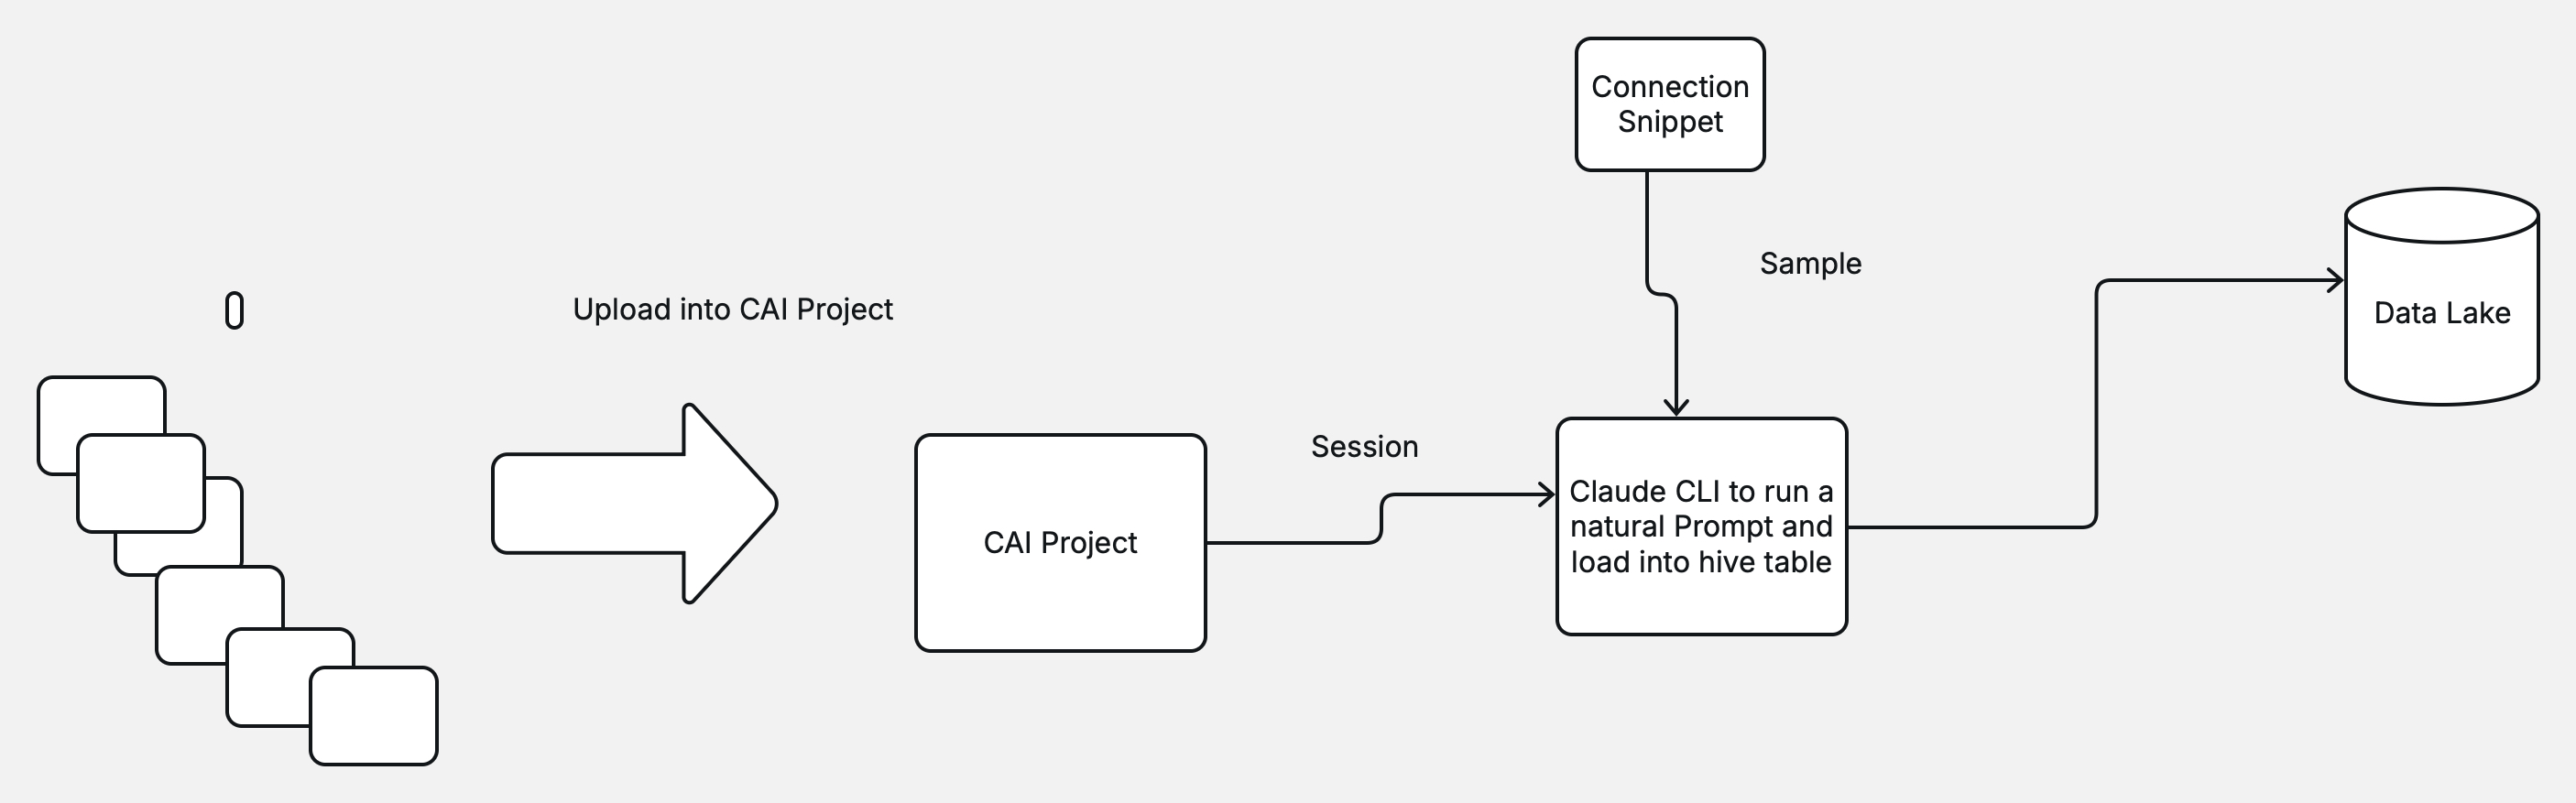

In [1]:
#!/usr/bin/env python3

import cml.data_v1 as cmldata
import json
import os
from datetime import datetime

# Connection details
CONNECTION_NAME = "default-hive-aws"

# Sample data file
SAMPLE_DATA_FILE = "sample_metric_data.json"

Function to connect to the Database and return the connection

In [2]:
# Function to connect to CDW
def connect_to_cdw():
    try:
        # Try to get a connection
        conn = cmldata.get_connection(CONNECTION_NAME)
        
        print("Successfully connected to CDW")
         
        ## Get DB API Cursor interface
        db_cursor = conn.get_cursor()
        print("Connection successful, displaying tables:")
        db_cursor.execute("show tables")
    
        for row in db_cursor:
            print(row)
            
        return conn
    
    except Exception as e:
        print("Error connecting to CDW", e)
        import traceback
        traceback.print_exc()
        return None
    


# Connect to the CDW
conn = connect_to_cdw()

Successfully connected to CDW
Connection successful, displaying tables:
('a_demo_table',)
('active_cdsw___cml_subscriptions_pivot_table_1_9_1720711789',)
('adiboncdp',)
('adibusage',)
('agent_analysis_results',)
('airline_tweets',)
('airline_tweets_iceberg',)
('airline_tweets_iceberghive',)
('airline_tweets_iceberghive_mv',)
('airlines_snappy',)
('ais_temp',)
('anomaly_detection',)
('arcticdb_test_iceberg2',)
('asoni',)
('asoni_ice',)
('asoni_ice_t4',)
('australia_states',)
('bank_info_table',)
('batch_load_table',)
('batchloadiceberg',)
('belfast_landmarks',)
('bloomberg_transcripts',)
('bruce_ice',)
('bv_es_sonda',)
('ca_customer_issues_per_month_csv',)
('campaign_orchestration',)
('car_install',)
('car_sales',)
('card_transaction',)
('care_site',)
('carriers',)
('cartao_credito',)
('cc_data',)
('cc_info_table',)
('cc_lead_data',)
('ccdemo_countries_iceberg',)
('cdm_source',)
('cdp_unified_cloud_pricing',)
('cdp_vendor_pricing',)
('cdp_vendor_pricing2',)
('cdsw_resource_utilization_1

Function to flatten the Json and return the flattened Json

In [3]:
def flatten_json(input_file):
    """
    Flatten nested JSON objects and save to a new file.
    For each top-level object in the array, any nested objects are flattened
    by combining their key-value pairs with the parent object.
    Keys in nested objects override keys in parent objects with the same name.
    """
    # Read the input JSON file
    with open(input_file, 'r') as f:
        data = json.load(f)

    # Flatten each object in the array
    flattened_data = []
    for record in data:
        flat_record = {}

        # Copy all top-level fields first
        for key, value in record.items():
            # If value is a dict, flatten it
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_record[f"{key}_{subkey}"] = subvalue
            else:
                flat_record[key] = value

        flattened_data.append(flat_record)

    # Write the flattened output
    #with open(output_file, 'w') as f:
    #    json.dump(flattened_data, f, indent=2)

    #print(f"Successfully flattened {input_file} and saved to {output_file}")
    return flattened_data

# Flatten Json
fdf = flatten_json(SAMPLE_DATA_FILE)
print(f"Flattened Data: {fdf}")

Flattened Data: [{'metric_ts': '2026-08-11T16:05:00Z', 'service_name': 'payment-gateway', 'environment': 'production', 'metric_name': 'http_request_duration_seconds', 'metric_type': 'histogram', 'value': 2.45, 'status': 'critical', 'tags_endpoint': '/v1/charge', 'tags_method': 'POST', 'tags_status_code': 504, 'tags_region': 'us-east-1'}, {'metric_ts': '2026-08-11T16:05:10Z', 'service_name': 'auth-service', 'environment': 'production', 'metric_name': 'cpu_utilization_percentage', 'metric_type': 'gauge', 'value': 88.2, 'status': 'warning', 'tags_container_id': 'auth-prod-02', 'tags_cluster': 'kubernetes-main', 'tags_region': 'us-west-2'}]


In [7]:
def infer_schema_from_json(data):
    """
    Infer SQL schema across ALL flattened records.
    Returns:
        {
            "metric_ts": "TIMESTAMP",
            "service_name": "STRING",
            ...
        }
    """
    schema = {}
    # Process each field in the first item
    for item in data:
        for key, value in item.items():
            if isinstance(value, str):
                schema[key] = {"type": "string"}
            elif isinstance(value, int):
                schema[key] = {"type": "integer"}
            elif isinstance(value, float):
                schema[key] = {"type": "number"}
            elif isinstance(value, bool):
                schema[key] = {"type": "boolean"}
            elif isinstance(value, list):
                schema[key] = {"type": "array", "items": infer_json_schema(value)}
            elif isinstance(value, dict):
                schema[key] = {"type": "object", "properties": infer_json_schema([value])["properties"]}
            else:
                continue  # Skip unsupported types
    return schema


# Infer schema
schema = infer_schema_from_json(fdf)
print(schema)

{'metric_ts': {'type': 'string'}, 'service_name': {'type': 'string'}, 'environment': {'type': 'string'}, 'metric_name': {'type': 'string'}, 'metric_type': {'type': 'string'}, 'value': {'type': 'number'}, 'status': {'type': 'string'}, 'tags_endpoint': {'type': 'string'}, 'tags_method': {'type': 'string'}, 'tags_status_code': {'type': 'integer'}, 'tags_region': {'type': 'string'}, 'tags_container_id': {'type': 'string'}, 'tags_cluster': {'type': 'string'}}


In [8]:
# Function to get database schema as CREATE TABLE statement
def get_create_table_statement(vschema, table_name):
    """Generate CREATE TABLE SQL from schema dict."""
    columns = []
    for col_name, col_type in vschema.items():
        # All columns are STRING now (standard columns + tag keys)
        col_def = f"{col_name} STRING"
        columns.append(col_def)

    return f"""CREATE TABLE {table_name} (
        id INT,
        {',        '.join(columns)}
        )"""

TABLE_NAME = "syn_metrics_1"
create_query = get_create_table_statement(schema, TABLE_NAME)
print(f"Creating new table: {TABLE_NAME}")
print(create_query)
cursor = conn.get_cursor()
cursor.execute(f"DROP TABLE IF EXISTS {TABLE_NAME}")
cursor.execute(create_query)

Creating new table: syn_metrics_1
CREATE TABLE syn_metrics_1 (
        id INT,
        metric_ts STRING,        service_name STRING,        environment STRING,        metric_name STRING,        metric_type STRING,        value STRING,        status STRING,        tags_endpoint STRING,        tags_method STRING,        tags_status_code STRING,        tags_region STRING,        tags_container_id STRING,        tags_cluster STRING
        )


In [ ]:
# ============================================================
# Build INSERT values
# ============================================================

def get_record_columns_and_values(record, schema, record_id):
    """
    Generate columns and values using the SAME schema used
    to create the table.
    """

    columns = ["id"]
    values = [record_id]

    for column_name, sql_type in schema.items():

        columns.append(column_name)

        value = record.get(column_name)

        #value = convert_value(
        #    value,
        #    sql_type
        #)

        values.append(value)

    return columns, values

# Insert sample data
print(f"Inserting {len(fdf)} sample records...")

for record_id, record in enumerate(
            fdf,
            start=1
        ):

    columns, values = (
        get_record_columns_and_values(
        record,
        schema,
        record_id
        )
    )

    placeholders = ", ".join(["%s"] * len(values))

    query = f"""INSERT INTO {TABLE_NAME}({", ".join(columns)}) VALUES ({placeholders})"""

    print(f"Inserting record {record_id}")

    cursor.execute(query,values)


Inserting 2 sample records...
Inserting record 1


In [42]:
# Verify data is loaded by querying table
verify_query = f"SELECT COUNT(*) FROM default.{TABLE_NAME}"

cursor.execute(verify_query)
count = cursor.fetchone()[0]
print(f"Total rows in {table_name}: {count}")

Total rows in syn_metrics_1: 4
